In [1]:
import sys
from pathlib import Path

PROJECT_DIR = Path.cwd().parent
sys.path.append(PROJECT_DIR.as_posix())

In [11]:
import pandas
import tensorflow

from src.models import (
    create_baseline_cnn,
    create_baseline_resnet,
    create_efficientNetB0,
    create_mobileNetV2,
    create_resnet_custom,
)
from src.preprocessor import (
    encode_labels,
    get_augmentation_layer,
    normalize_images,
    resize_images,
)
from src.training import (
    compile_model,
    compute_metrics,
    evaluate_and_store,
    plot_history,
    train_model,
)

## Chargement des données

In [3]:
(X_train_fine, y_train_fine), (X_test_fine, y_test_fine) = (
    tensorflow.keras.datasets.cifar100.load_data(label_mode="fine")
)

# (X_train_coarse, y_train_coarse), (X_test_coarse, y_test_coarse) = (
#     tensorflow.keras.datasets.cifar100.load_data(label_mode="coarse")
# )

c:\Users\Administrateur\Documents\tp_groupe_tensorflow\.venv\Lib\site-packages\keras\src\datasets\cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


## Normalisation des données

In [4]:
train_ds_fine = tensorflow.data.Dataset.from_tensor_slices((X_train_fine, y_train_fine))
test_ds_fine = tensorflow.data.Dataset.from_tensor_slices((X_test_fine, y_test_fine))

train_ds_fine_normalized = normalize_images(train_ds_fine, normalization="none")
test_ds_fine_normalized = normalize_images(test_ds_fine, normalization="none")

train_ds_fine_encoded = encode_labels(train_ds_fine_normalized, label_mode="fine")
test_ds_fine_encoded = encode_labels(test_ds_fine_normalized, label_mode="fine")

IMG_SIZE = 32

train_ds_fine_resized = resize_images(train_ds_fine_encoded, image_size=IMG_SIZE)
test_ds_fine_resized = resize_images(test_ds_fine_encoded, image_size=IMG_SIZE)

# train_ds_fine_mix_up = mix_up_images(train_ds_fine_resized)

BATCH_SIZE = 32

train_ds_fine_processed = (
    train_ds_fine_resized.cache()
    .shuffle(1000)
    .batch(BATCH_SIZE)
    .prefetch(tensorflow.data.AUTOTUNE)
)
test_ds_fine_processed = (
    test_ds_fine_resized.cache().batch(BATCH_SIZE).prefetch(tensorflow.data.AUTOTUNE)
)

In [5]:
# train_ds_coarse = tensorflow.data.Dataset.from_tensor_slices(
#     (X_train_coarse, y_train_coarse)
# )
# test_ds_coarse = tensorflow.data.Dataset.from_tensor_slices(
#     (X_test_coarse, y_test_coarse)
# )

# train_ds_coarse_normalized = normalize_images(train_ds_coarse, normalization="none")
# test_ds_coarse_normalized = normalize_images(test_ds_coarse, normalization="none")

# train_ds_coarse_encoded = encode_labels(train_ds_coarse_normalized, label_mode="coarse")
# test_ds_coarse_encoded = encode_labels(test_ds_coarse_normalized, label_mode="coarse")

# train_ds_coarse_mix_up = mix_up_images(train_ds_coarse_encoded)

## Création des modèles

In [6]:
augmentation_layer = get_augmentation_layer()

models = {
    "Baseline": create_baseline_cnn(
        data_augmentation=augmentation_layer, img_size=IMG_SIZE
    ),
    "ResNet": create_baseline_resnet(
        data_augmentation=augmentation_layer, img_size=IMG_SIZE
    ),
    "ResNet_custom": create_resnet_custom(
        data_augmentation=augmentation_layer, img_size=IMG_SIZE
    ),
    "MobileNetV2": create_mobileNetV2(
        data_augmentation=augmentation_layer, img_size=IMG_SIZE
    ),
    "EfficientNetB0": create_efficientNetB0(
        data_augmentation=augmentation_layer, img_size=IMG_SIZE
    ),
    # "hierarchical": create_hierarchical_model(
    #     data_augmentation=augmentation_layer, img_size=IMG_SIZE
    # ),
}

c:\Users\Administrateur\Documents\tp_groupe_tensorflow\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users/Administrateur/Documents/tp_groupe_tensorflow\src\models.py:116: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = keras.applications.MobileNetV2(


## Entraînement des modèles

In [7]:
callbacks = [
    tensorflow.keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=3, restore_best_weights=True, verbose=1
    ),
    tensorflow.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", patience=3, factor=0.5, verbose=1
    ),
    # tensorflow.keras.callbacks.ModelCheckpoint(
    #     filepath="models/best_model_demo.h5",
    #     monitor="val_accuracy",
    #     save_best_only=True,
    #     mode="max",
    #     verbose=1
    # )
]

histories = {}
for name, model in models.items():
    print(f"{name} model compilation...")
    models[name] = compile_model(model=model)
    print(f"{name} model training...")
    histories[name] = train_model(
        model=model,
        train_ds=train_ds_fine_processed,
        train_val=test_ds_fine_processed,
        callbacks=callbacks,
    )
    print(f"{name} model trained")

Baseline model compilation...
Baseline model training...
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 49s 30ms/step - accuracy: 0.0092 - loss: 4.6732 - val_accuracy: 0.0100 - val_loss: 4.6169 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 1.
Baseline model trained
ResNet model compilation...
ResNet model training...
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 349s 222ms/step - accuracy: 0.0086 - loss: 5.1781 - val_accuracy: 0.0100 - val_loss: 4.6052 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 1.
ResNet model trained
ResNet_custom model compilation...
ResNet_custom model training...
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 28s 17ms/step - accuracy: 0.0099 - loss: 4.6143 - val_accuracy: 0.0109 - val_loss: 4.6119 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 1.
ResNet_custom model trained
MobileNetV2 model compilation...
MobileNetV2 model training...
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 36s 21ms/step - accuracy: 0.0095 - loss: 4.

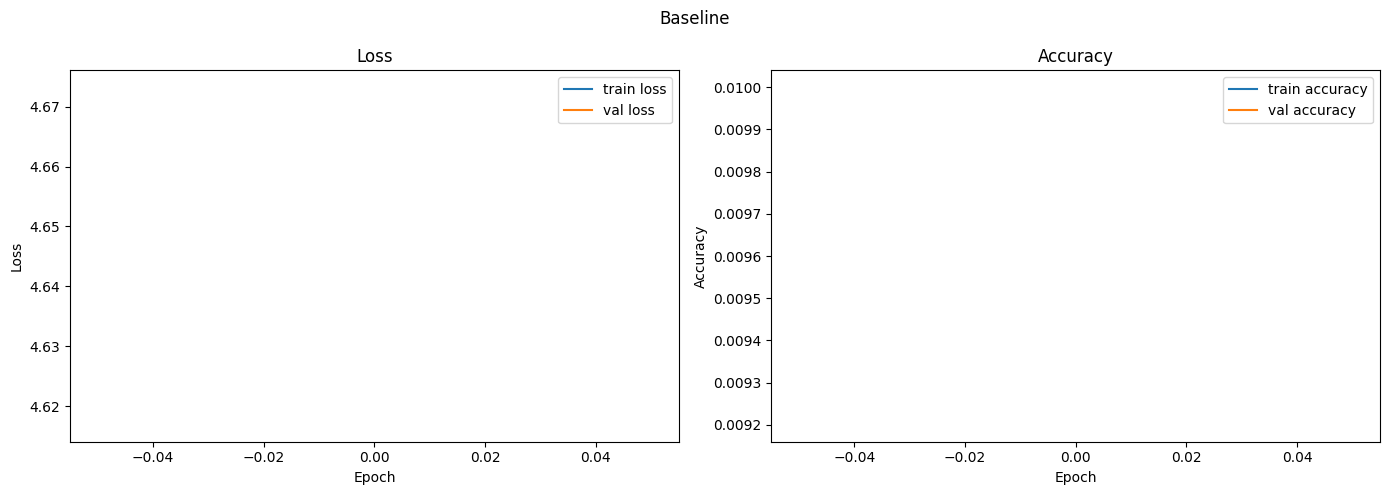

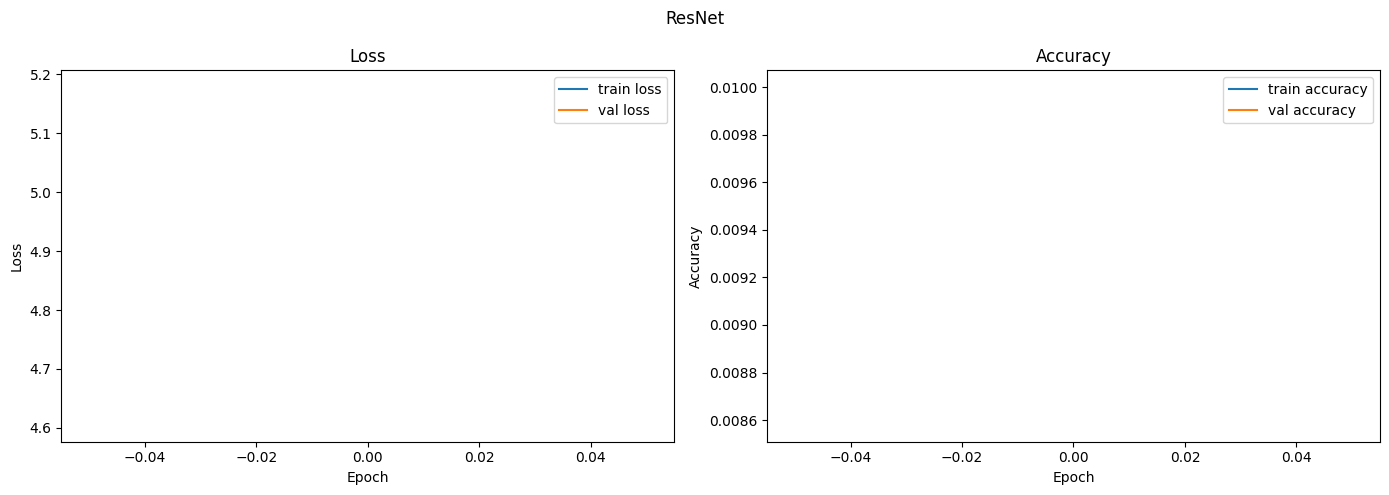

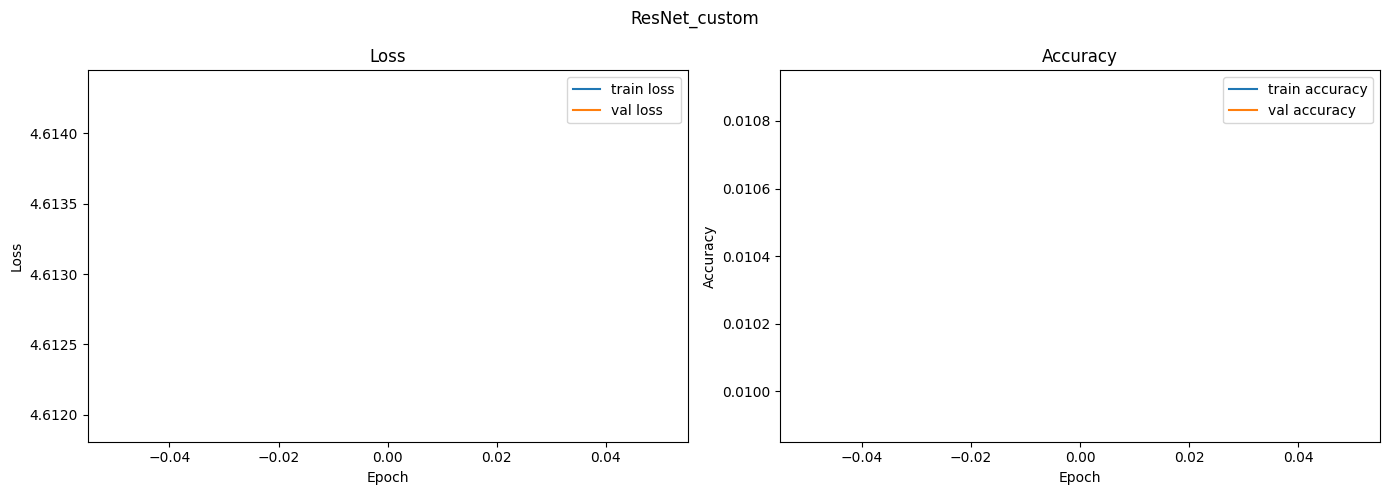

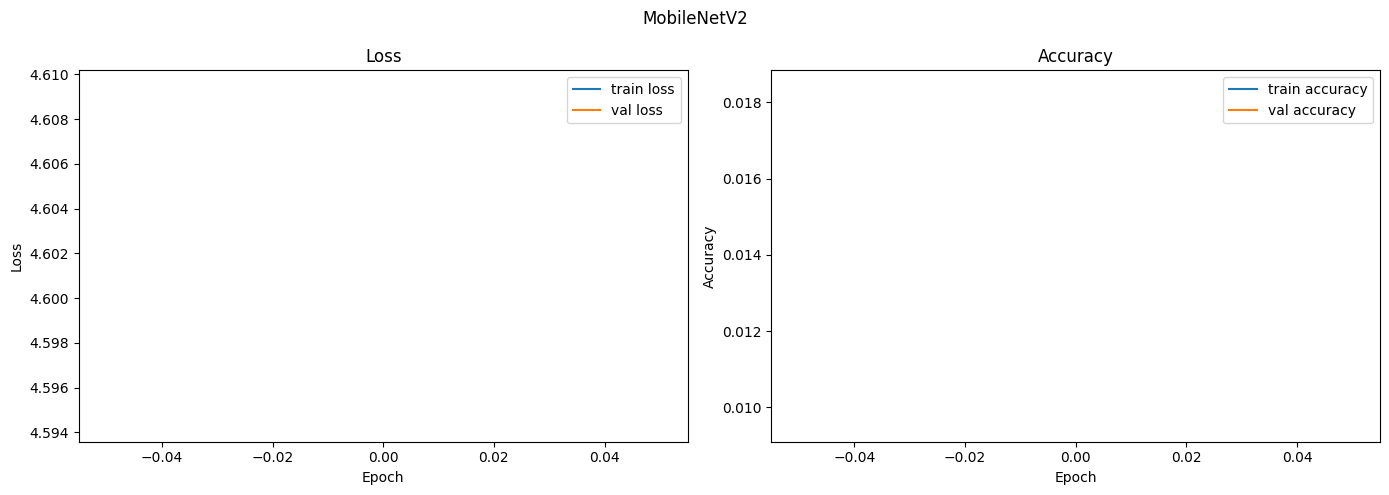

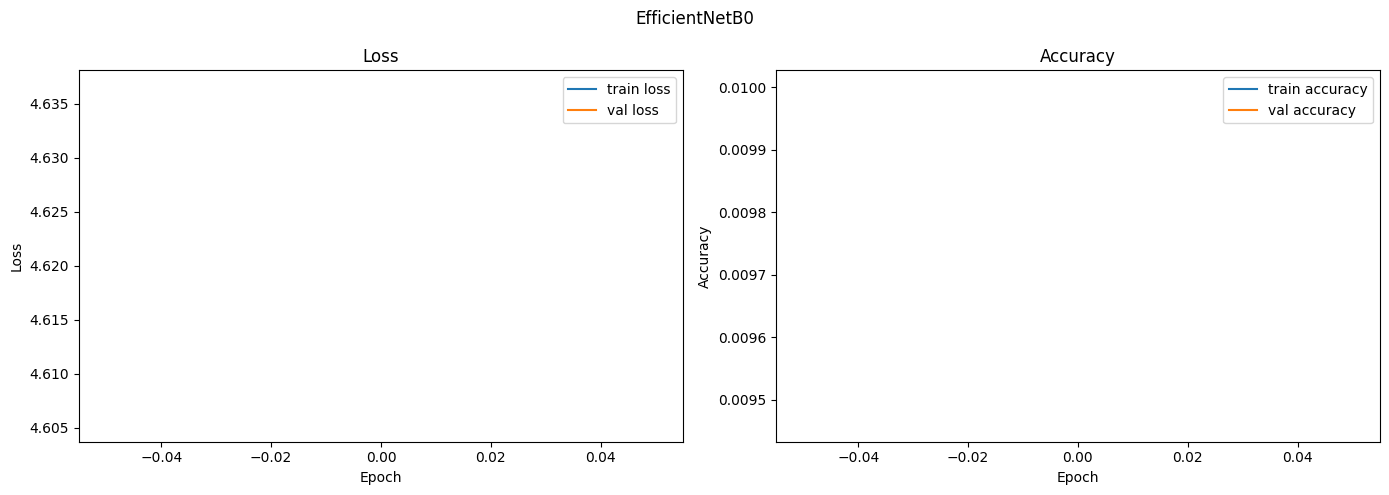

In [8]:
for name, history in histories.items():
    plot_history(history=history, model_name=name)

In [9]:
predict_labels = {}
for name, model in models.items():
    predict_labels[name] = compute_metrics(model=model, test_ds=test_ds_fine_processed)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 47ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step


In [10]:
for name, model in models.items():
    evaluate_and_store(model=model, model_name=name, test_ds=test_ds_fine_processed)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
Accuracy: 0.0100
Top-3 Accuracy: 0.0293
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
CSV exported !
313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 46ms/step
Accuracy: 0.0100
Top-3 Accuracy: 0.0300
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step
CSV exported !
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Accuracy: 0.0109
Top-3 Accuracy: 0.0333
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
CSV exported !
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step
Accuracy: 0.0184
Top-3 Accuracy: 0.0428
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 200ms/step
CSV exported !
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step
Accuracy: 0.0100
Top-3 Accuracy: 0.0300
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 373ms/step
CSV exported !


In [ ]:
paths = []
for name in models.keys():
    paths.append(PROJECT_DIR / "notebooks" / "output" / "result" / f"{name}.csv")


def load_and_concat_csv(paths: list[str]) -> pandas.DataFrame:
    dataframes = [pandas.read_csv(path) for path in paths]
    return pandas.concat(dataframes, ignore_index=True)


models_comparisons = load_and_concat_csv(paths=paths)
models_comparisons.sort_values("F1", ascending=False).head()

,Architecture,Top-1 Acc,Top-5 Acc,F1,Speed (ms)
3,MobileNetV2,0.018,0.043,0.006,11.58
2,ResNet_custom,0.011,0.033,0.001,1.94
0,Baseline,0.010,0.029,0.000,1.89
1,ResNet,0.010,0.030,0.000,6.41
4,EfficientNetB0,0.010,0.030,0.000,21.40
